# Recommended Regression Analysis Tools

This notebook demonstrates every key regression technique from Lectures 6 and 7 using the actual JRGS project data. All code cells run end-to-end on the cleaned AUS enrolment and funding datasets.

**Research question:** Did the Job-ready Graduates Package increase student enrolments in STEM, health, and education compared with society & culture and creative arts?

---

## Contents

1. [Environment Setup and Data Loading](#1-environment-setup-and-data-loading)
2. [OLS Regression — Core Tool](#2-ols-regression--core-tool)
3. [Robust Standard Errors (HC3)](#3-robust-standard-errors-hc3)
4. [OLS Mechanics and the β̂ Formula](#4-ols-mechanics-and-the-β̂-formula)
5. [Frisch-Waugh-Lovell: Partialling Out Controls](#5-frisch-waugh-lovell-partialling-out-controls)
6. [Omitted Variable Bias (OVB)](#6-omitted-variable-bias-ovb)
7. [Exogeneity Failures to Watch For](#7-exogeneity-failures-to-watch-for)
8. [Dummy Variables and Categorical Controls](#8-dummy-variables-and-categorical-controls)
9. [Interaction Terms](#9-interaction-terms)
10. [Functional Forms](#10-functional-forms)
11. [Quadratic Terms](#11-quadratic-terms)
12. [Fixed Effects (Entity and Time)](#12-fixed-effects-entity-and-time)
13. [Two-Way Fixed Effects (TWFE)](#13-two-way-fixed-effects-twfe)
14. [Difference-in-Differences](#14-difference-in-differences)
15. [Parallel Trends Check (Event Study)](#15-parallel-trends-check-event-study)
16. [Interpreting Output](#16-interpreting-output)

## 1. Environment Setup and Data Loading

Load the cleaned enrolment and funding datasets, reshape to panel format, and build all treatment indicators used throughout.

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# --- Locate project root portably ---
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir is not None, f"Cannot find data/clean from {Path.cwd()}"
print('data/clean:', clean_dir)

# --- Load enrolments (wide) and melt to long panel ---
enrol_wide = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')

year_cols = [c for c in enrol_wide.columns if c.isdigit()]
df = enrol_wide.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments'
)
df['year'] = df['year'].astype(int)

# Drop aggregate rows
df = df[~df['Category'].isin(['Total', 'Others'])].copy()
df = df.dropna(subset=['enrollments'])
df['enrollments'] = df['enrollments'].astype(float)

# --- Log outcome (log-linear specification) ---
df['log_enrollments'] = np.log(df['enrollments'])

# --- JRG treatment indicators ---
# Treated: categories where JRG reduced fees (STEM, Health, Education, Environment)
# Control:  categories where JRG increased fees (Society & Culture, Creative Arts,
#            Management & Commerce, Architecture & Building)
treated_cats = {
    'Natural & Physical Science',
    'Information Technology',
    'Engineering & Related Tech',
    'Health',
    'Education',
    'Environment & Related',
}
df['treated']  = df['Category'].isin(treated_cats).astype(int)
df['post_jrg'] = (df['year'] >= 2021).astype(int)
df['did']      = df['treated'] * df['post_jrg']     # DiD interaction
df['year_c']   = df['year'] - 2019                  # centre year at 2019
df['year_c2']  = df['year_c'] ** 2                  # quadratic time trend

# --- Load funding and compute category-year averages ---
fund = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
fund_agg = (
    fund.groupby(['Year', 'CategoryKey'])
    [['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .reset_index()
    .rename(columns={'Year': 'year'})
)
fund_agg['total_funding'] = (
    fund_agg['MaximumStudentContribution'] + fund_agg['CommonwealthContribution']
)

df = df.merge(fund_agg, on=['year', 'CategoryKey'], how='left')
df['log_funding']      = np.log(df['total_funding'].clip(lower=1))
df['log_commonwealth'] = np.log(df['CommonwealthContribution'].clip(lower=1))

print(f"Panel shape: {df.shape}")
print(f"Categories: {sorted(df['Category'].unique())}")
print(f"Years: {sorted(df['year'].unique())}")
display(df.head())

data/clean: c:\Users\neddp\ECC3479-Project-JRGS\data\clean
Panel shape: (90, 15)
Categories: ['Architecture & Building', 'Creative Arts', 'Education', 'Engineering & Related Tech', 'Environment & Related', 'Health', 'Information Technology', 'Management & Commerce', 'Natural & Physical Science', 'Society & Culture']
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,Category,CategoryKey,year,enrollments,log_enrollments,treated,post_jrg,did,year_c,year_c2,MaximumStudentContribution,CommonwealthContribution,total_funding,log_funding,log_commonwealth
0,Natural & Physical Science,1,2016,119102.0,11.687736,1,0,0,-3,9,NaN,NaN,NaN,NaN,NaN
1,Information Technology,2,2016,66355.0,11.102774,1,0,0,-3,9,NaN,NaN,NaN,NaN,NaN
2,Engineering & Related Tech,3,2016,111060.0,11.617826,1,0,0,-3,9,NaN,NaN,NaN,NaN,NaN
3,Architecture & Building,4,2016,32074.0,10.375801,0,0,0,-3,9,NaN,NaN,NaN,NaN,NaN
4,Environment & Related,5,2016,18537.0,9.827524,1,0,0,-3,9,NaN,NaN,NaN,NaN,NaN


## 2. OLS Regression — Core Tool

OLS minimises the sum of squared residuals:

$$\min_{\hat{\beta}} \sum_{i=1}^{n} \hat{u}_i^2 = \sum_{i=1}^{n} (Y_i - \hat{\beta}_0 - \hat{\beta}_1 X_i)^2$$

Use `statsmodels` formula API (`smf.ols`) — it accepts R-style formula strings and handles the intercept automatically.

In [9]:
# Bivariate OLS: log enrollments on post-JRG indicator
model_biv = smf.ols("log_enrollments ~ post_jrg", data=df).fit(cov_type="HC3")
print("=== Bivariate OLS ===")
print(model_biv.summary())

=== Bivariate OLS ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.1177
Date:                Wed, 22 Apr 2026   Prob (F-statistic):              0.732
Time:                        11:17:14   Log-Likelihood:                -115.80
No. Observations:                  90   AIC:                             235.6
Df Residuals:                      88   BIC:                             240.6
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.6566      0.1

In [10]:
# Multivariate OLS: add year trend and category controls
model_multi = smf.ols(
    "log_enrollments ~ post_jrg + year_c + C(Category)",
    data=df
).fit(cov_type="HC3")
print("=== Multivariate OLS ===")
print(model_multi.summary())

=== Multivariate OLS ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1499.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           6.40e-86
Time:                        11:17:14   Log-Likelihood:                 94.500
No. Observations:                  90   AIC:                            -165.0
Df Residuals:                      78   BIC:                            -135.0
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

## 3. Robust Standard Errors (HC3)

Always use `cov_type="HC3"` (heteroskedasticity-consistent). Valid even when homoskedasticity holds — never harmful, protects against invalid inference when error variance is not constant.

- **HC3** (MacKinnon-White): the recommended default from the lectures.
- Never rely on conventional (non-robust) SEs for policy-relevant inference.

In [11]:
# Compare conventional vs. HC3 standard errors
result_conv = smf.ols("log_enrollments ~ post_jrg + year_c", data=df).fit()
result_hc3  = smf.ols("log_enrollments ~ post_jrg + year_c", data=df).fit(cov_type="HC3")

comparison = pd.DataFrame({
    'Coef':         result_hc3.params.round(4),
    'SE (conv)':    result_conv.bse.round(4),
    'SE (HC3)':     result_hc3.bse.round(4),
    'p (conv)':     result_conv.pvalues.round(4),
    'p (HC3)':      result_hc3.pvalues.round(4),
})
print("Conventional vs. HC3 robust standard errors:")
display(comparison)

print("\n95% confidence intervals (HC3):")
display(result_hc3.conf_int().round(4))

Conventional vs. HC3 robust standard errors:


,Coef,SE (conv),SE (HC3),p (conv),p (HC3)
Intercept,11.6879,0.1454,0.1467,0.0000,0.0000
post_jrg,-0.0758,0.3777,0.3800,0.8414,0.8419
year_c,0.0313,0.0727,0.0745,0.6677,0.6741



95% confidence intervals (HC3):


,0,1
Intercept,11.4004,11.9753
post_jrg,-0.8206,0.6690
year_c,-0.1146,0.1773


## 4. OLS Mechanics and the β̂ Formula

For simple regression $Y = \beta_0 + \beta_1 X + u$:

$$\hat{\beta}_1 = \frac{\widehat{\text{Cov}}(X, Y)}{\widehat{\text{Var}}(X)}, \qquad \hat{\beta}_0 = \bar{Y} - \hat{\beta}_1 \bar{X}$$

**Model fit statistics:**
- **R²**: proportion of variance in Y explained by X. $R^2 = 1 - SSR/SST$.
- **F-statistic**: joint significance of all slope coefficients.
- **t-statistic**: $t = \hat{\beta}_1 / \text{SE}(\hat{\beta}_1)$. Under H₀, distributed ≈ N(0,1) in large samples.

In [12]:
# Manual β̂₁ calculation vs. statsmodels — should match exactly
sub = df[['log_enrollments', 'year_c']].dropna()
beta1_hat = sub['log_enrollments'].cov(sub['year_c']) / sub['year_c'].var()
beta0_hat = sub['log_enrollments'].mean() - beta1_hat * sub['year_c'].mean()
print(f"Manual  β̂₁ = {beta1_hat:.6f}")
print(f"Manual  β̂₀ = {beta0_hat:.6f}")

result = smf.ols("log_enrollments ~ year_c", data=df).fit(cov_type="HC3")
print(f"\nstatsmodels Intercept = {result.params['Intercept']:.6f}")
print(f"statsmodels year_c    = {result.params['year_c']:.6f}")
print(f"\nR² = {result.rsquared:.4f} | F-stat = {result.fvalue:.2f} | N = {int(result.nobs)}")

Manual  β̂₁ = 0.018674
Manual  β̂₀ = 11.666806

statsmodels Intercept = 11.666806
statsmodels year_c    = 0.018674

R² = 0.0030 | F-stat = 0.25 | N = 90


## 5. Frisch-Waugh-Lovell: Partialling Out Controls

The **FWL theorem** states that in $Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + u$, the coefficient $\hat{\beta}_1$ is numerically identical to the slope from regressing **residuals of Y on X₂** against **residuals of X₁ on X₂**.

**Practical implication:** adding controls removes variation in both Y and X₁ attributable to the controls, leaving only "clean" within-group variation.

In [13]:
# Partial out year_c from both log_enrollments and post_jrg
sub = df[['log_enrollments', 'post_jrg', 'year_c']].dropna()

resid_Y  = smf.ols("log_enrollments ~ year_c", data=sub).fit().resid
resid_X1 = smf.ols("post_jrg ~ year_c",        data=sub).fit().resid

tmp = pd.DataFrame({'resid_Y': resid_Y, 'resid_X1': resid_X1})
fwl_result  = smf.ols("resid_Y ~ resid_X1", data=tmp).fit()
full_result = smf.ols("log_enrollments ~ post_jrg + year_c", data=sub).fit(cov_type="HC3")

print(f"FWL β̂(post_jrg)  = {fwl_result.params['resid_X1']:.6f}")
print(f"Full β̂(post_jrg) = {full_result.params['post_jrg']:.6f}")
print("\nCoefficients match ✓" if abs(fwl_result.params['resid_X1'] - full_result.params['post_jrg']) < 1e-9 else "Mismatch!")

FWL β̂(post_jrg)  = -0.075809
Full β̂(post_jrg) = -0.075809

Coefficients match ✓


## 6. Omitted Variable Bias (OVB)

If the true model includes $X_2$ but we omit it:

$$\tilde{\beta}_1 = \hat{\beta}_1 + \hat{\beta}_2 \cdot \hat{\gamma}_1$$

where $\hat{\gamma}_1$ is from the auxiliary regression of $X_2$ on $X_1$.

**Sign of bias:**

| β̂₂ (omitted → Y) | γ̂₁ (omitted ↔ included) | Bias |
|---|---|---|
| + | + | Upward |
| + | − | Downward |
| − | + | Downward |
| − | − | Upward |

**For JRGS:** omitting `year_c` (a time trend) biases `post_jrg` because later years have higher enrolments and also coincide with post-JRG period.

In [14]:
long_reg  = smf.ols("log_enrollments ~ post_jrg + year_c", data=df).fit(cov_type="HC3")
short_reg = smf.ols("log_enrollments ~ post_jrg",           data=df).fit(cov_type="HC3")
aux_reg   = smf.ols("year_c ~ post_jrg",                    data=df).fit()

beta2_hat  = long_reg.params['year_c']
gamma1_hat = aux_reg.params['post_jrg']
ovb        = beta2_hat * gamma1_hat

print(f"Long  β̂(post_jrg) = {long_reg.params['post_jrg']:.4f}  [year_c controlled]")
print(f"Short β̃(post_jrg) = {short_reg.params['post_jrg']:.4f}  [year_c omitted]")
print(f"Difference         = {short_reg.params['post_jrg'] - long_reg.params['post_jrg']:.4f}")
print(f"OVB formula check  = β̂₂ × γ̂₁ = {beta2_hat:.4f} × {gamma1_hat:.4f} = {ovb:.4f}")

Long  β̂(post_jrg) = -0.0758  [year_c controlled]
Short β̃(post_jrg) = 0.0651  [year_c omitted]
Difference         = 0.1409
OVB formula check  = β̂₂ × γ̂₁ = 0.0313 × 4.5000 = 0.1409


## 7. Exogeneity Failures to Watch For

OLS requires $E[u \mid X] = 0$. There are four main failure modes:

| Failure mode | Description | JRGS example |
|---|---|---|
| **Omitted Variable Bias** | Relevant variable correlated with X left out | Pre-existing enrolment trends by category |
| **Reverse Causality** | Y causes X (or both) | Government targeted already-declining categories |
| **Measurement Error** | X measured with noise → attenuation bias | Enrolment counts aggregated differently across years |
| **Sample Selection** | Sample not representative of population | Only TEQSA-reporting universities included |

**Mitigation:** Fixed effects and DiD address OVB from time-invariant confounders; the parallel trends assumption is the key identifying assumption for DiD.

## 8. Dummy Variables and Categorical Controls

For a categorical variable with $k$ levels, include $k - 1$ dummies (one absorbed into the intercept as the baseline).

Use `C(variable)` in the formula — statsmodels handles dummy creation automatically, choosing the alphabetically first level as baseline.

**For JRGS:** `C(Category)` controls for stable between-category enrolment level differences.

In [15]:
# C(Category) adds k-1 dummies; alphabetically first is the baseline
model_cat = smf.ols(
    "log_enrollments ~ post_jrg + year_c + C(Category)",
    data=df
).fit(cov_type="HC3")

# Show only non-category coefficients for clarity
non_cat = model_cat.params[~model_cat.params.index.str.startswith('C(Category)')]
print("Non-category coefficients:")
display(pd.DataFrame({'Coef': non_cat.round(4), 'p-value': model_cat.pvalues[non_cat.index].round(4)}))

# Change reference category to 'Society & Culture' explicitly
model_ref = smf.ols(
    "log_enrollments ~ post_jrg + year_c + C(Category, Treatment('Society & Culture'))",
    data=df
).fit(cov_type="HC3")
cat_coefs = model_ref.params[model_ref.params.index.str.startswith('C(Category')]
print("\nCategory dummies (reference = Society & Culture):")
display(pd.DataFrame({'Coef': cat_coefs.round(4), 'p-value': model_ref.pvalues[cat_coefs.index].round(4)}))

Non-category coefficients:


,Coef,p-value
Intercept,10.6005,0.0000
post_jrg,-0.0758,0.0243
year_c,0.0313,0.0010



Category dummies (reference = Society & Culture):


,Coef,p-value
"C(Category, Treatment('Society & Culture'))[T.Architecture & Building]",-2.1111,0.0000
"C(Category, Treatment('Society & Culture'))[T.Creative Arts]",-1.2410,0.0000
"C(Category, Treatment('Society & Culture'))[T.Education]",-0.8985,0.0000
"C(Category, Treatment('Society & Culture'))[T.Engineering & Related Tech]",-1.0454,0.0000
"C(Category, Treatment('Society & Culture'))[T.Environment & Related]",-2.8390,0.0000
"C(Category, Treatment('Society & Culture'))[T.Health]",-0.2058,0.0000
"C(Category, Treatment('Society & Culture'))[T.Information Technology]",-1.0968,0.0000
"C(Category, Treatment('Society & Culture'))[T.Management & Commerce]",0.1226,0.0011
"C(Category, Treatment('Society & Culture'))[T.Natural & Physical Science]",-0.9223,0.0000


## 9. Interaction Terms

An interaction lets the effect of one variable differ by the value of another:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 D + \beta_3 (X_1 \times D) + u$$

- When $D = 0$: slope on $X_1$ is $\beta_1$
- When $D = 1$: slope on $X_1$ is $\beta_1 + \beta_3$

Use `*` in the formula (main effects included automatically). Use `:` for the raw interaction term only.

**For JRGS:** `treated * post_jrg` is the core DiD interaction.

In [16]:
# Interaction between treated status and post-JRG dummy
model_int = smf.ols(
    "log_enrollments ~ treated * post_jrg + year_c",
    data=df
).fit(cov_type="HC3")
print(model_int.summary())

# Marginal effect of post_jrg for treated vs. control
b = model_int.params
effect_control = b['post_jrg']
effect_treated = b['post_jrg'] + b['treated:post_jrg']
print(f"\npost_jrg effect for control group:  {effect_control:.4f}")
print(f"post_jrg effect for treated group:  {effect_treated:.4f}")
print(f"DiD estimate (treated:post_jrg):    {b['treated:post_jrg']:.4f}")

                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9119
Date:                Wed, 22 Apr 2026   Prob (F-statistic):              0.461
Time:                        11:17:15   Log-Likelihood:                -113.80
No. Observations:                  90   AIC:                             237.6
Df Residuals:                      85   BIC:                             250.1
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           11.9308      0.235  

## 10. Functional Forms

Choose the functional form based on how you want to interpret the coefficient:

| Model | Specification | Interpretation of β̂₁ |
|---|---|---|
| **Level-level** | $Y = \beta_0 + \beta_1 X$ | 1 unit ↑ X → β̂₁ units ↑ Y |
| **Log-linear** (semi-elasticity) | $\ln Y = \beta_0 + \beta_1 X$ | 1 unit ↑ X → 100·β̂₁ % ↑ Y |
| **Level-log** | $Y = \beta_0 + \beta_1 \ln X$ | 1% ↑ X → β̂₁/100 units ↑ Y |
| **Log-log** (elasticity) | $\ln Y = \beta_0 + \beta_1 \ln X$ | 1% ↑ X → β̂₁ % ↑ Y |

**For JRGS:** **log-linear** is preferred — percentage changes are comparable across categories of very different enrolment scale.

In [17]:
# Level-level
m_ll = smf.ols("enrollments ~ post_jrg + year_c", data=df).fit(cov_type="HC3")

# Log-linear (preferred)
m_loglin = smf.ols("log_enrollments ~ post_jrg + year_c", data=df).fit(cov_type="HC3")

# Log-log: outcome and predictor both in logs (only where funding data exists)
df_fund = df.dropna(subset=['log_funding', 'log_enrollments'])
m_loglog = smf.ols("log_enrollments ~ log_funding + year_c + C(Category)", data=df_fund).fit(cov_type="HC3")

print("=== Level-level: post_jrg coefficient ===")
print(f"  β̂ = {m_ll.params['post_jrg']:,.0f} enrolments")

print("\n=== Log-linear: post_jrg coefficient ===")
coef = m_loglin.params['post_jrg']
print(f"  β̂ = {coef:.4f}  →  approx. {coef*100:.2f}% change in enrolments")

print("\n=== Log-log: total funding elasticity ===")
elas = m_loglog.params['log_funding']
print(f"  β̂ = {elas:.4f}  →  1% ↑ funding → {elas:.4f}% ↑ enrolments")

=== Level-level: post_jrg coefficient ===
  β̂ = -10,495 enrolments

=== Log-linear: post_jrg coefficient ===
  β̂ = -0.0758  →  approx. -7.58% change in enrolments

=== Log-log: total funding elasticity ===
  β̂ = 0.1260  →  1% ↑ funding → 0.1260% ↑ enrolments


## 11. Quadratic Terms

A quadratic in X allows a non-linear (U-shaped or inverted-U) relationship:

$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + u$$

The marginal effect of X depends on X: $\partial Y / \partial X = \beta_1 + 2\beta_2 X$.

Create the squared term as a column first, then include it.

In [18]:
# Quadratic time trend — already have year_c and year_c2
model_quad = smf.ols(
    "log_enrollments ~ year_c + year_c2 + post_jrg + C(Category)",
    data=df
).fit(cov_type="HC3")

b1 = model_quad.params['year_c']
b2 = model_quad.params['year_c2']
print(f"year_c coef  (β₁) = {b1:.4f}")
print(f"year_c2 coef (β₂) = {b2:.4f}")

# Marginal effect of year at specific points
for yr in [2017, 2019, 2021, 2023]:
    yc = yr - 2019
    me = b1 + 2 * b2 * yc
    print(f"  ∂(log_enrol)/∂year at {yr}: {me:.4f}  (~{me*100:.2f}% per year)")

year_c coef  (β₁) = 0.0342
year_c2 coef (β₂) = -0.0029
  ∂(log_enrol)/∂year at 2017: 0.0459  (~4.59% per year)
  ∂(log_enrol)/∂year at 2019: 0.0342  (~3.42% per year)
  ∂(log_enrol)/∂year at 2021: 0.0226  (~2.26% per year)
  ∂(log_enrol)/∂year at 2023: 0.0109  (~1.09% per year)


## 12. Fixed Effects (Entity and Time)

**Entity fixed effects** ($\alpha_i$): absorb all time-invariant, entity-level confounders. Equivalent to within-group demeaning.

$$Y_{it} = \alpha_i + \beta X_{it} + u_{it}$$

**Time fixed effects** ($\gamma_t$): absorb all entity-invariant year shocks (e.g. COVID, macro trends).

Use `linearmodels.panel.PanelOLS`. The DataFrame **must** be indexed by `(entity, time)` before passing to the model.

**For JRGS:** entity = Category, time = year.

In [19]:
# PanelOLS requires a MultiIndex: (entity, time)
df_panel = df.set_index(['Category', 'year'])

# Entity fixed effects only
fe_entity = PanelOLS(
    df_panel['log_enrollments'],
    df_panel[['post_jrg']],
    entity_effects=True
).fit(cov_type='robust')
print("=== Entity FE ===")
print(fe_entity.summary)

# Time fixed effects only
fe_time = PanelOLS(
    df_panel['log_enrollments'],
    df_panel[['treated']],
    time_effects=True
).fit(cov_type='robust')
print("\n=== Time FE ===")
print(fe_time.summary)

=== Entity FE ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.1062
Estimator:                   PanelOLS   R-squared (Between):              0.0049
No. Observations:                  90   R-squared (Within):               0.1062
Date:                Wed, Apr 22 2026   R-squared (Overall):              0.0049
Time:                        11:17:15   Log-likelihood                    85.263
Cov. Estimator:                Robust                                           
                                        F-statistic:                      9.3853
Entities:                          10   P-value                           0.0030
Avg Obs:                       9.0000   Distribution:                    F(1,79)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             9.8396
          

## 13. Two-Way Fixed Effects (TWFE)

Combines entity and time FE:

$$Y_{it} = \alpha_i + \gamma_t + \beta X_{it} + u_{it}$$

Controls for:
- All time-invariant category differences ($\alpha_i$)
- All category-invariant year shocks ($\gamma_t$)

$\beta$ is identified from **within-category, within-year** variation in X — the cleanest non-experimental estimator.

**For JRGS:** TWFE is the preferred baseline specification.

In [20]:
# Two-way fixed effects: entity + time
twfe = PanelOLS(
    df_panel['log_enrollments'],
    df_panel[['did']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='robust')
print("=== TWFE: DiD via PanelOLS ===")
print(twfe.summary)

=== TWFE: DiD via PanelOLS ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.0881
Estimator:                   PanelOLS   R-squared (Between):              0.0045
No. Observations:                  90   R-squared (Within):               0.1651
Date:                Wed, Apr 22 2026   R-squared (Overall):              0.0045
Time:                        11:17:15   Log-likelihood                    101.89
Cov. Estimator:                Robust                                           
                                        F-statistic:                      6.8583
Entities:                          10   P-value                           0.0108
Avg Obs:                       9.0000   Distribution:                    F(1,71)
Min Obs:                       9.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             8.54

In [21]:
# TWFE with additional time-varying controls (funding data, post-2019 only)
df_fund_panel = df.dropna(subset=['log_funding']).set_index(['Category', 'year'])

twfe_controls = PanelOLS(
    df_fund_panel['log_enrollments'],
    df_fund_panel[['did', 'log_funding', 'log_commonwealth']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='robust')
print("=== TWFE with funding controls ===")
print(twfe_controls.summary)

=== TWFE with funding controls ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.2354
Estimator:                   PanelOLS   R-squared (Between):              0.6222
No. Observations:                  60   R-squared (Within):               0.1622
Date:                Wed, Apr 22 2026   R-squared (Overall):              0.6222
Time:                        11:17:15   Log-likelihood                    101.88
Cov. Estimator:                Robust                                           
                                        F-statistic:                      4.3100
Entities:                          10   P-value                           0.0097
Avg Obs:                       6.0000   Distribution:                    F(3,42)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):             

## 14. Difference-in-Differences

$$Y_{it} = \alpha_i + \gamma_t + \beta \cdot (\text{Treated}_i \times \text{Post}_t) + u_{it}$$

$\beta$ is the **ATT** — the average enrolment change for treated categories relative to what they would have experienced had they followed the control trend.

**Key assumption:** parallel trends — treated and control categories would have trended identically in the absence of JRG.

**Note on staggered DiD:** when treatment turns on at different times for different units, standard TWFE uses already-treated units as controls, contaminating the estimate (Goodman-Bacon 2021). Here JRG applied simultaneously in 2021, so standard DiD is appropriate.

In [22]:
# DiD via OLS with category and year dummies (equivalent to TWFE)
did_ols = smf.ols(
    "log_enrollments ~ did + C(Category) + C(year)",
    data=df
).fit(cov_type="HC3")

print(f"DiD estimate (OLS):   {did_ols.params['did']:.4f}")
print(f"95% CI:               [{did_ols.conf_int().loc['did', 0]:.4f}, {did_ols.conf_int().loc['did', 1]:.4f}]")
print(f"p-value:              {did_ols.pvalues['did']:.4f}")
print(f"Interpretation:       {did_ols.params['did']*100:.2f}% relative enrolment change for treated categories post-JRG")

# Confirm it matches TWFE PanelOLS estimate
print(f"\nDiD estimate (TWFE):  {twfe.params['did']:.4f}")

DiD estimate (OLS):   0.0996
95% CI:               [0.0244, 0.1747]
p-value:              0.0094
Interpretation:       9.96% relative enrolment change for treated categories post-JRG

DiD estimate (TWFE):  0.0996


## 15. Parallel Trends Check (Event Study)

Estimate year-by-year DiD coefficients relative to the last pre-treatment year (2020). If treated and control trended similarly before 2021, the parallel trends assumption is plausible — pre-treatment coefficients should be statistically indistinguishable from zero.

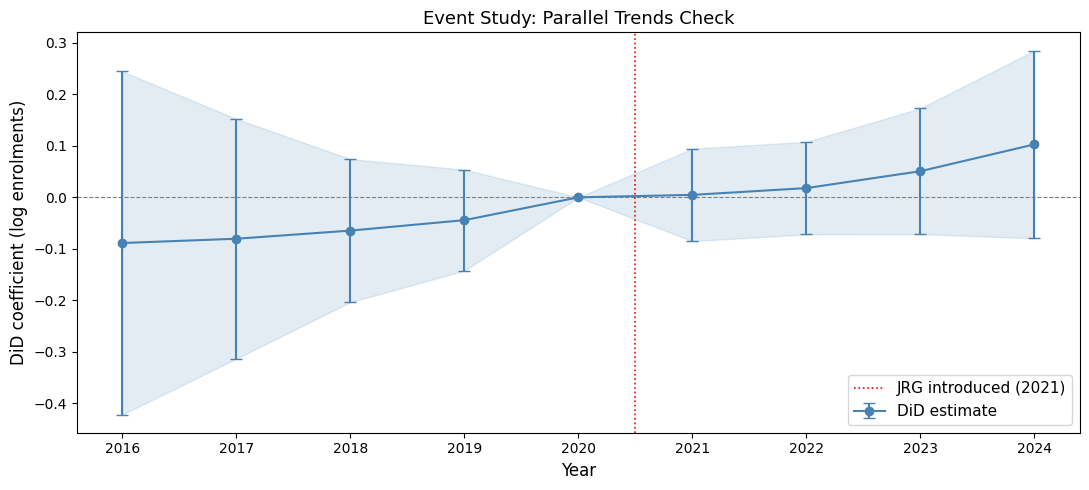


Event study coefficients:


,coef,ci_lo,ci_hi
year,,,
2016,-0.0887,-0.4215,0.2442
2017,-0.0803,-0.3128,0.1521
2018,-0.0646,-0.2034,0.0742
2019,-0.0443,-0.1422,0.0537
2020,0.0000,0.0000,0.0000
2021,0.0047,-0.0850,0.0945
2022,0.0179,-0.0718,0.1077
2023,0.0507,-0.0714,0.1728
2024,0.1027,-0.0794,0.2848


In [23]:
years = sorted(df['year'].unique())
base_year = 2020
event_rows = []

for yr in years:
    if yr == base_year:
        event_rows.append({'year': yr, 'coef': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0})
        continue
    tmp = df[df['year'].isin([base_year, yr])].copy()
    tmp['post'] = (tmp['year'] == yr).astype(int)
    tmp['interaction'] = tmp['treated'] * tmp['post']
    m = smf.ols("log_enrollments ~ interaction + C(Category) + post", data=tmp).fit(cov_type='HC3')
    ci = m.conf_int().loc['interaction']
    event_rows.append({'year': yr, 'coef': m.params['interaction'], 'ci_lo': ci[0], 'ci_hi': ci[1]})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.2, label='JRG introduced (2021)')
ax.errorbar(
    ev['year'], ev['coef'],
    yerr=[ev['coef'] - ev['ci_lo'], ev['ci_hi'] - ev['coef']],
    fmt='o-', color='steelblue', capsize=4, linewidth=1.5, label='DiD estimate'
)
ax.fill_between(ev['year'], ev['ci_lo'], ev['ci_hi'], alpha=0.15, color='steelblue')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments)', fontsize=12)
ax.set_title('Event Study: Parallel Trends Check', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nEvent study coefficients:")
display(ev.set_index('year').round(4))

## 16. Interpreting Output

Key numbers to report from any regression table:

| Statistic | statsmodels attribute | Meaning |
|---|---|---|
| **β̂** | `result.params['var']` | Estimated effect size |
| **Robust SE** | `result.bse['var']` | Uncertainty in β̂ |
| **t-statistic** | `result.tvalues['var']` | β̂ / SE |
| **p-value** | `result.pvalues['var']` | P(\|t\| ≥ observed \| H₀) |
| **95% CI** | `result.conf_int()` | Range of plausible values |
| **R²** | `result.rsquared` | Proportion of Y variance explained |
| **Adj. R²** | `result.rsquared_adj` | R² penalised for extra regressors |
| **F-statistic** | `result.fvalue` | Joint significance of all slopes |

In [24]:
def regression_summary(result, key_vars=None):
    """Concise table: β̂, SE, t, p, 95% CI for selected variables."""
    ci = result.conf_int()
    rows = []
    for var in (key_vars or result.params.index):
        rows.append({
            'Variable':  var,
            'β̂':         round(result.params[var], 4),
            'SE (HC3)':  round(result.bse[var], 4),
            't':         round(result.tvalues[var], 3),
            'p':         round(result.pvalues[var], 4),
            '95% CI lo': round(ci.loc[var, 0], 4),
            '95% CI hi': round(ci.loc[var, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f"R² = {result.rsquared:.4f} | Adj. R² = {result.rsquared_adj:.4f} | N = {int(result.nobs)}")

# Summarise the main DiD OLS result
print("=== DiD OLS — key coefficients ===")
regression_summary(did_ols, key_vars=['did'])

=== DiD OLS — key coefficients ===


,β̂,SE (HC3),t,p,95% CI lo,95% CI hi
Variable,,,,,,
did,0.0996,0.0383,2.597,0.0094,0.0244,0.1747


R² = 0.9921 | Adj. R² = 0.9901 | N = 90
